<a href="https://colab.research.google.com/github/anikaumaselvan/academic_projects/blob/main/Final_Project_Notebook_DS_3001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Group Members: Anika Umaselvan (aua3jg), Anika Shah (yvc4fq), Malia Solomon (zxe4mj), Maryam Ahmed (prg7sj), and Adhira Prasanna (tyz8qg)

# **RESEARCH QUESTION AND DATA SET RECAP:**



The topic of our project is diabetes health indicators, with a focus on how demographics and health-related variables correlate with diabetes prevalence in the United States. We are using a dataset from the Centers for Disease Control and Prevention (CDC), our project aims to examine how individual characteristics and lifestyle behaviors are associated with diabetes outcomes. Our specific research question is: how do demographic and health-related varaibles correlate with diabetes status. The specific predictor features we are focusing on include: age, sex, body mass index (BMI), smoking status, and fruit consumption. By analyzing these specific correlations, we aim to better understand which variables are most associated and predictive of diabetes and how these factors vary across individuals. This will help provide an extensive and well-rounded outcome for analysis in correlation to diabetes as we will be studying it from all domains.




# **DATA WRANGLING**

Our team will begin by loading in the dataframe and inspecting the head of the dataset to get an intuitive understanding of its structure.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # For changing directory
import zipfile # Import for unzipping files

# To mount your google drive
from google.colab import drive
drive.mount('/content/drive')

#since each of us have different paths to our directory we each coded them out individually and #'ed them
path_to_DS_3001_folder = '/content/drive/MyDrive/DS 3001/data'
# path_to_DS_3001_folder = ''
#path_to_DS_3001_folder ='/content/drive/MyDrive/DS-3001/02_Intro_to_ML_Algorithms'


# Update the path to your folder for the class
# Where you stored the data from the previous noteboook
os.chdir(path_to_DS_3001_folder)

# List contents of the directory to debug FileNotFoundError
#print(f"Contents of {path_to_DS_3001_folder}:")
#print(os.listdir('.'))

# List contents of the 'Data' directory to debug further
#print(f"Contents of ./data/:") # Changed 'Data' to 'data'
#print(os.listdir('./data')) # Changed 'Data' to 'data'

# Define the path to the zipped file
#zip_file_path = './data/diabetes_012_health_indicators_BRFSS2015.csv.zip' # Changed 'Data' to 'data'
# Define the directory where you want to extract the CSV
#extract_dir = './data/' # Changed 'Data' to 'data'

# Check if the CSV already exists (to avoid re-unzipping every time)
#csv_file_name = 'diabetes_012_health_indicators_BRFSS2015.csv'
#csv_file_path = os.path.join(extract_dir, csv_file_name)

#if not os.path.exists(csv_file_path):
    # Unzip the file if the CSV does not exist
    #with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        #zip_ref.extractall(extract_dir)
    #print(f"Unzipped {zip_file_path} to {extract_dir}")
#else:
    #print(f"CSV file already exists at {csv_file_path}, skipping unzipping.")

diabetes_df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv', sep=',')
#diabetes_df = pd.read_csv('./data/diabetes_012_health_indicators_BRFSS2015.csv.zip', sep=',') # Changed 'Data' to 'data'
#diabetes_df = pd.read_csv(csv_file_path, sep=',')
diabetes_df.head()

Mounted at /content/drive


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

Looking at the datatypes of the columns, all are stored as floats and are numerical values. This will make the dataset easier to work with, but from previous inspection of the observations seen in the head of the diabetes dataframe, we think it might be useful to treat many the columns as binary values rather than true numeric values.

In [ ]:
missing_values_count = diabetes_df.isnull().sum()
missing_values_percentage = (diabetes_df.isnull().sum() / len(diabetes_df)) * 100

missing_info_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

missing_info_df = missing_info_df.sort_values(by='Missing Percentage (%)', ascending=False)

print("Missing Values Information:")
print(missing_info_df[missing_info_df['Missing Count'] > 0])

Missing Values Information:
Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []


The dataset does not have any missing values within it, which is ideal, and can be seen as the dataframe of missing values is returned as empty.

In [ ]:
print("Descriptive Statistics:")
print(diabetes_df.describe())

Descriptive Statistics:
        Diabetes_012         HighBP       HighChol      CholCheck  \
count  253680.000000  253680.000000  253680.000000  253680.000000   
mean        0.296921       0.429001       0.424121       0.962670   
std         0.698160       0.494934       0.494210       0.189571   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       1.000000   
50%         0.000000       0.000000       0.000000       1.000000   
75%         0.000000       1.000000       1.000000       1.000000   
max         2.000000       1.000000       1.000000       1.000000   

                 BMI         Smoker         Stroke  HeartDiseaseorAttack  \
count  253680.000000  253680.000000  253680.000000         253680.000000   
mean       28.382364       0.443169       0.040571              0.094186   
std         6.608694       0.496761       0.197294              0.292087   
min        12.000000       0.000000       0.000000

Knowing that all of the columns have numeric data types, we can take a look at the descriptive statistics. By looking at these, it helps to understand the types of values which fall under each column, whether or not they are binary, and what is the range of numeric values.

In [ ]:
print("Unique Value Counts:")
print(diabetes_df.nunique())

Unique Value Counts:
Diabetes_012             3
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64


Looking at the number of unique value counts under each column expands on our previous understanding of the dataset, and matches up with the codebook. For example, many of the binary columns only have two unique values ( 0 or 1 ) while other columns like BMI have a multitude of unique values as our dataset contains over 200k observations, it is natural there is a wide amount of unique values of BMI.

In [ ]:
new_column_names = {
    'Diabetes_012': 'Diabetes',
    'HighBP': 'HighBloodPressure',
    'HighChol': 'HighCholesterol',
    'CholCheck': 'CholesterolChecked',
    'HvyAlcoholConsump': 'HeavyAlcoholConsumption',
    'PhysActivity': 'PhysicalActivity',
    'GenHlth': 'GeneralHealth',
    'MentHlth': 'MentalHealth',
    'PhysHlth': 'PhysicalHealth',
    'DiffWalk': 'DifficultyWalking'
}

diabetes_df.rename(columns=new_column_names, inplace=True)

print("Updated Column Names:")
print(diabetes_df.columns)

Updated Column Names:
Index(['Diabetes', 'HighBloodPressure', 'HighCholesterol',
       'CholesterolChecked', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
       'PhysicalActivity', 'Fruits', 'Veggies', 'HeavyAlcoholConsumption',
       'AnyHealthcare', 'NoDocbcCost', 'GeneralHealth', 'MentalHealth',
       'PhysicalHealth', 'DifficultyWalking', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


While the dataset did not have any missing values, the column names were not consistent in terms of formatting nor communicative of what they represented. We decided to go through and update the columnn names in a consistent manner that would make code easier to follow and would make writing future code more communicative.

In [ ]:
# Columns to convert to int32 ( binary or ordinal columns )
binary_ordinal_cols = [
    'HighBloodPressure', 'HighCholesterol', 'CholesterolChecked', 'Smoker',
    'Stroke', 'HeartDiseaseorAttack', 'PhysicalActivity', 'Fruits', 'Veggies',
    'HeavyAlcoholConsumption', 'AnyHealthcare', 'NoDocbcCost', 'DifficultyWalking',
    'Sex', 'GeneralHealth', 'Age', 'Education', 'Income'
]

for col in binary_ordinal_cols:
    # Convert to int32
    diabetes_df[col] = diabetes_df[col].astype('int32')

# The target variable 'Diabetes' can also be converted to int32
dia_map = {0.0: 0, 1.0: 1, 2.0: 2}
diabetes_df['Diabetes'] = diabetes_df['Diabetes'].map(dia_map).astype('int32')

print("Data types after optimization:")
print(diabetes_df.info())

Data types after optimization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Diabetes                 253680 non-null  int32  
 1   HighBloodPressure        253680 non-null  int32  
 2   HighCholesterol          253680 non-null  int32  
 3   CholesterolChecked       253680 non-null  int32  
 4   BMI                      253680 non-null  float64
 5   Smoker                   253680 non-null  int32  
 6   Stroke                   253680 non-null  int32  
 7   HeartDiseaseorAttack     253680 non-null  int32  
 8   PhysicalActivity         253680 non-null  int32  
 9   Fruits                   253680 non-null  int32  
 10  Veggies                  253680 non-null  int32  
 11  HeavyAlcoholConsumption  253680 non-null  int32  
 12  AnyHealthcare            253680 non-null  int32  
 13  NoDocbcCost              253

Our first attempt at changing datatypes was to convert the binary columns and the ones that had small ranges (Like Education with the values 1,2,3,4,5,6) into int32 because there was no need for those columns to be floats, so this simplified the storage of our dataset for future work with the values.

In [ ]:
bool_cols = [
    'HighBloodPressure', 'HighCholesterol', 'CholesterolChecked', 'Smoker',
    'Stroke', 'HeartDiseaseorAttack', 'PhysicalActivity', 'Fruits', 'Veggies',
    'HeavyAlcoholConsumption', 'AnyHealthcare', 'NoDocbcCost', 'DifficultyWalking',
    'Sex'
]

for col in bool_cols:
    diabetes_df[col] = diabetes_df[col].astype(int)

print("Data types after converting binary columns to int (0/1):")
print(diabetes_df.info())

Data types after converting binary columns to int (0/1):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Diabetes                 253680 non-null  int32  
 1   HighBloodPressure        253680 non-null  int64  
 2   HighCholesterol          253680 non-null  int64  
 3   CholesterolChecked       253680 non-null  int64  
 4   BMI                      253680 non-null  float64
 5   Smoker                   253680 non-null  int64  
 6   Stroke                   253680 non-null  int64  
 7   HeartDiseaseorAttack     253680 non-null  int64  
 8   PhysicalActivity         253680 non-null  int64  
 9   Fruits                   253680 non-null  int64  
 10  Veggies                  253680 non-null  int64  
 11  HeavyAlcoholConsumption  253680 non-null  int64  
 12  AnyHealthcare            253680 non-null  int64  
 13  No

After reconsideration, we actually added another code segment to convert the binary columns into int32, as the binary columns often represented 0 = no/false and 1 = yes/true.

# **Perform Exploratory Data Analysis (EDA):**

1a) Identify whether your numeric varaibles (both the target and explanatory variables) are on a reasonable scale without large tails or outliers.

In [ ]:
diabetes_df.describe()



,Diabetes,HighBloodPressure,HighCholesterol,CholesterolChecked,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysicalActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GeneralHealth,MentalHealth,PhysicalHealth,DifficultyWalking,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


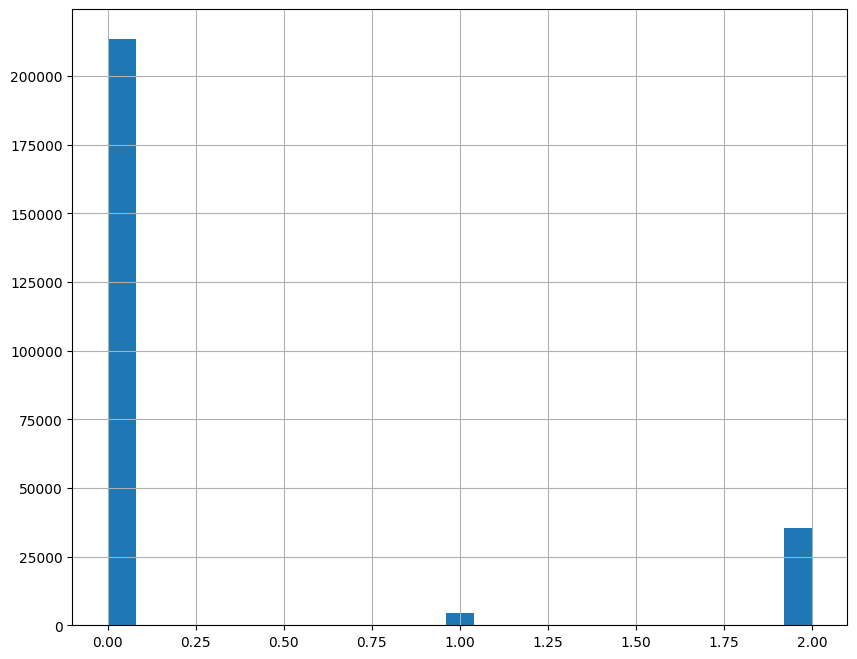

In [ ]:
#Diabetes graph
diabetes_df['Diabetes'].hist(bins=25, figsize=(10,8))

plt.show()

Interpretation: This graph demonstrates bad distribution that is right skewed.

1b) If not, implement methods to handle the scale or outliers.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
diabetes_df_scaled=scaler.fit_transform(diabetes_df)
diabetes_df_scaled

array([[0.        , 1.        , 1.        , ..., 0.66666667, 0.6       ,
        0.28571429],
       [0.        , 0.        , 0.        , ..., 0.5       , 1.        ,
        0.        ],
       [0.        , 1.        , 1.        , ..., 0.66666667, 0.6       ,
        1.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.08333333, 0.8       ,
        0.14285714],
       [0.        , 1.        , 0.        , ..., 0.5       , 0.8       ,
        0.        ],
       [1.        , 1.        , 1.        , ..., 0.66666667, 1.        ,
        0.14285714]])

2a) To accompany the visualization, include the statistical description (e.g., mean, median, standard deviation, quartiles, min/max)

In [ ]:
vars_to_plot = ["Age", "Sex", "BMI", "Smoker", "Fruits"]

print(diabetes_df[vars_to_plot].describe())


print("\nMedian values:")
print(diabetes_df[vars_to_plot].median())

                 Age            Sex            BMI         Smoker  \
count  253680.000000  253680.000000  253680.000000  253680.000000   
mean        8.032119       0.440342      28.382364       0.443169   
std         3.054220       0.496429       6.608694       0.496761   
min         1.000000       0.000000      12.000000       0.000000   
25%         6.000000       0.000000      24.000000       0.000000   
50%         8.000000       0.000000      27.000000       0.000000   
75%        10.000000       1.000000      31.000000       1.000000   
max        13.000000       1.000000      98.000000       1.000000   

              Fruits  
count  253680.000000  
mean        0.634256  
std         0.481639  
min         0.000000  
25%         0.000000  
50%         1.000000  
75%         1.000000  
max         1.000000  

Median values:
Age        8.0
Sex        0.0
BMI       27.0
Smoker     0.0
Fruits     1.0
dtype: float64


2b) Create a visualization for the distrubution of each numeric variable you want to include in your future model. Pariplot to plot them all at once:

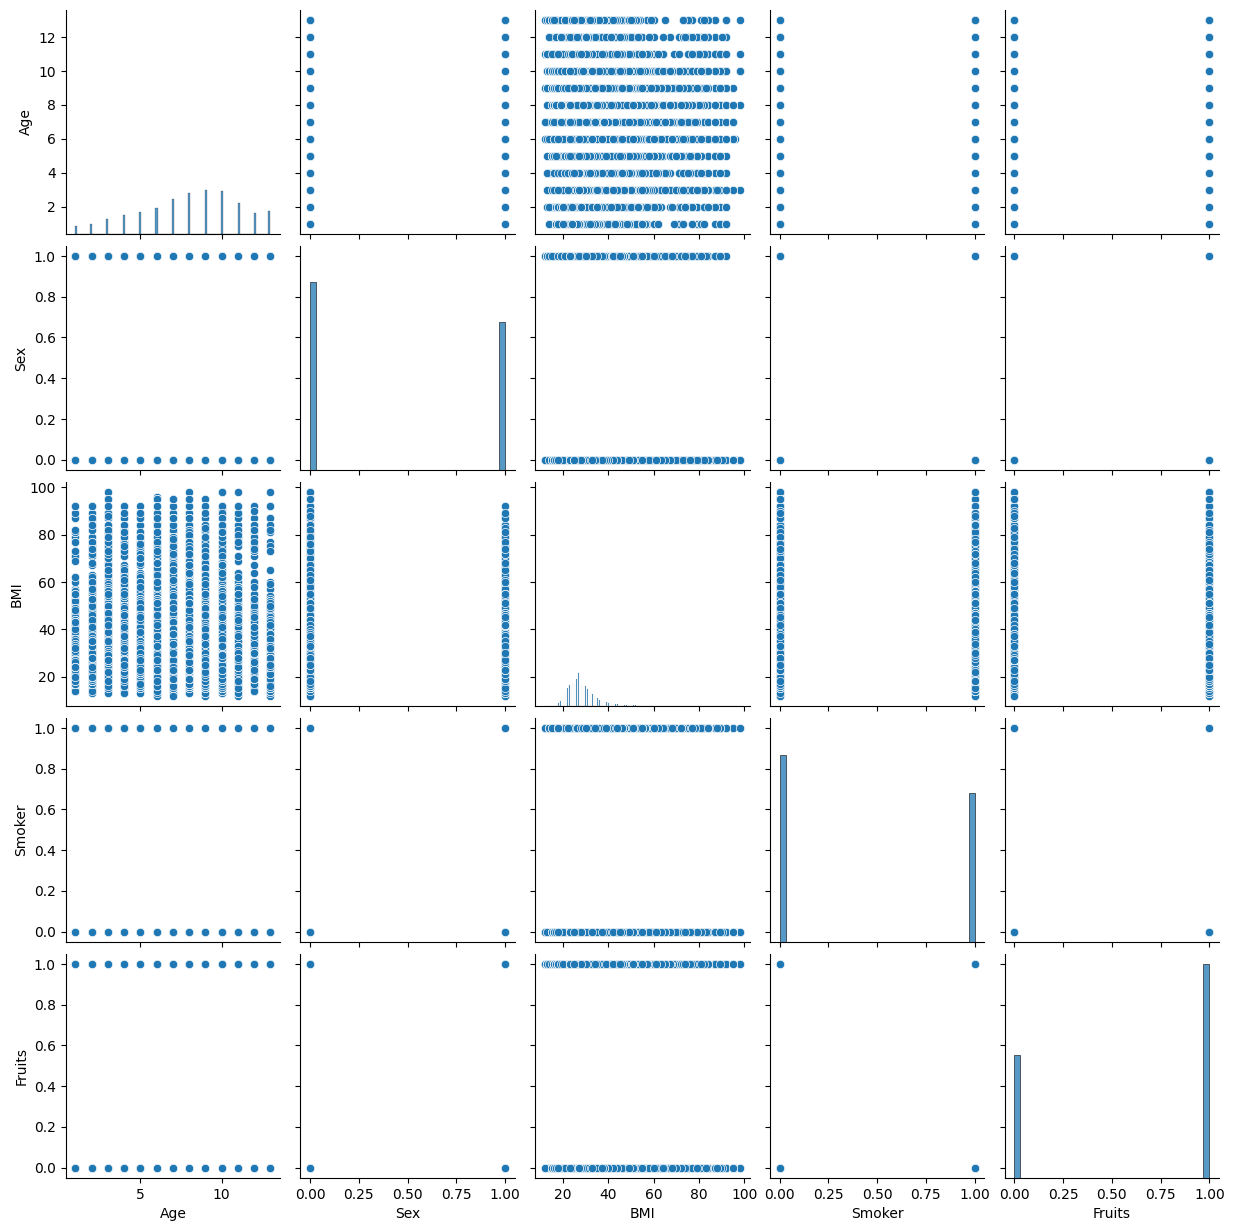

In [ ]:
#Pairplot graphs
sns.pairplot(diabetes_df[vars_to_plot], diag_kind="hist")

plt.show()

Interpretation: These are all the potential graphs that could exists comparing the variables. Some of them have good distribution, whereas some don't have distribution.

I find the Age, Sex graph the most interesting and would like to explore that one more in our final project to form an analysis of these variables influence on diabetes.

3)For categorical variables (both the target and explanatory variables), consider the number of observation in each class. Does there seem to be an imbalance in the classes?

In [ ]:
vars_to_plot = ['Age', 'Sex', 'BMI', 'Smoker', 'Fruits']

summary=diabetes_df[vars_to_plot].describe()

summary.loc['median'] = diabetes_df[vars_to_plot].median()

print(summary)

                  Age            Sex            BMI         Smoker  \
count   253680.000000  253680.000000  253680.000000  253680.000000   
mean         8.032119       0.440342      28.382364       0.443169   
std          3.054220       0.496429       6.608694       0.496761   
min          1.000000       0.000000      12.000000       0.000000   
25%          6.000000       0.000000      24.000000       0.000000   
50%          8.000000       0.000000      27.000000       0.000000   
75%         10.000000       1.000000      31.000000       1.000000   
max         13.000000       1.000000      98.000000       1.000000   
median       8.000000       0.000000      27.000000       0.000000   

               Fruits  
count   253680.000000  
mean         0.634256  
std          0.481639  
min          0.000000  
25%          0.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  
median       1.000000  


In [ ]:
#code for the smoking status
print(diabetes_df['Smoker'].value_counts())

#code for sex
print(diabetes_df['Sex'].value_counts())

#code for BMI
print(diabetes_df['BMI'].value_counts())

#code for age
print(diabetes_df['Age'].value_counts())

#code for fruit
print(diabetes_df['Fruits'].value_counts())

Smoker
0    141257
1    112423
Name: count, dtype: int64
Sex
0    141974
1    111706
Name: count, dtype: int64
BMI
27.0    24606
26.0    20562
24.0    19550
25.0    17146
28.0    16545
        ...  
85.0        1
86.0        1
91.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64
Age
9     33244
10    32194
8     30832
7     26314
11    23533
6     19819
13    17363
5     16157
12    15980
4     13823
3     11123
2      7598
1      5700
Name: count, dtype: int64
Fruits
1    160898
0     92782
Name: count, dtype: int64


There does seem to be a slight imbalance as for some of the different classes the findings are very similar to one another and somewhat in range of each other, but for others there is a drastic difference suggesting some level of imbalance accross classes; however, some classes have balance. It seems to be dependent on class.

4)Create at least 3 grouped visualizations of numeric distributions grouped by a categorical variable. Describe how the distribution changes for each group in that categorical variable. Could these trends be informative in a model?

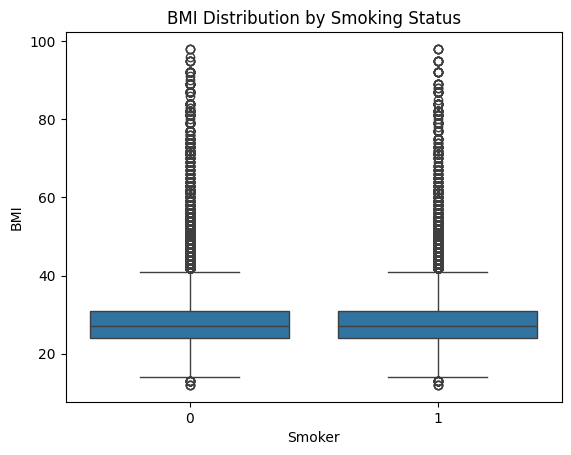

In [ ]:
sns.boxplot(x="Smoker", y="BMI", data=diabetes_df)
plt.title("BMI Distribution by Smoking Status")
plt.show()

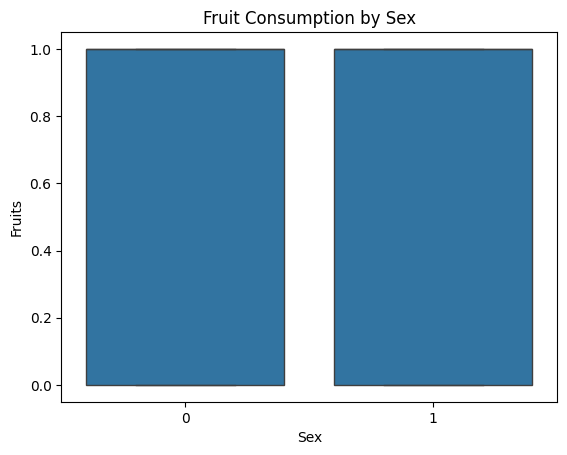

In [ ]:
sns.boxplot(x="Sex", y="Fruits", data=diabetes_df)
plt.title("Fruit Consumption by Sex")
plt.show()

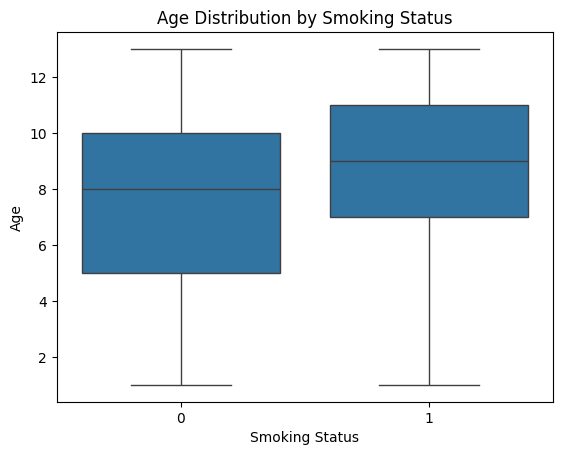

In [ ]:
sns.boxplot(x="Smoker", y="Age", data=diabetes_df)

plt.title("Age Distribution by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Age")

plt.show()

There is no difference between in BMI in smokers and non-smokers as shown by the first graph in this section, because the medians look to be essentially equal and the ranges overlap a lot. For the fruit consumption by sex there also does not seem to be a difference if someone consumes fruit in comparison to sex. Because of how wide it is fruit consumption has zero correlation to sex. Smoking and age appear to have a slight correlation; however, there is still considerable overlap between both sets of people so you can't come to any particular conclusion in particular, but due to the box plots it would be plausible that age plays a part in smoking and non-smoking.

5) Create statistical descriptions (e.g., mean, median, standard deviation, quartiles, min/max) of the numeric variables grouped by categorical variable for each of the grouped visualizations you created:


In [ ]:
# BMI grouped by Smoker
diabetes_df.groupby('Smoker')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
Smoker,,,,,,,,
0,141257.0,28.300976,6.655762,12.0,24.0,27.0,31.0,98.0
1,112423.0,28.484625,6.547671,12.0,24.0,27.0,31.0,98.0


In [ ]:
# Fruits grouped by Sex

diabetes_df.groupby('Sex')['Fruits'].describe()

,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
0,141974.0,0.673208,0.469042,0.0,0.0,1.0,1.0,1.0
1,111706.0,0.584749,0.492767,0.0,0.0,1.0,1.0,1.0


In [ ]:
# Age grouped by Smoker
diabetes_df.groupby('Smoker')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Smoker,,,,,,,,
0,141257.0,7.703406,3.148583,1.0,5.0,8.0,10.0,13.0
1,112423.0,8.445140,2.878638,1.0,7.0,9.0,11.0,13.0


In [ ]:
diabetes_df.groupby('Smoker')['BMI'].agg(['mean','median','std','min','max'])

,mean,median,std,min,max
Smoker,,,,,
0,28.300976,27.0,6.655762,12.0,98.0
1,28.484625,27.0,6.547671,12.0,98.0


Describe how these statistics change for each group within a categorical variable. Could these differences be informative in a model?

Answer:

BMI by Smoking Status: Mean BMI is nearly identical (28.30 non-smokers vs 28.48 smokers) and medians are the same (27), with very similar standard deviations (~6.5–6.6) and identical ranges (12–98). This indicates no meaningful difference in BMI across groups, suggesting smoking is not a strong independent predictor of BMI but may still be useful in interaction terms.

Fruits by Sex: Both groups have the same binary distribution (top value = True in both, with similar counts), indicating minimal difference across sexes. This suggests fruit consumption does not vary meaningfully by sex and is unlikely to contribute significant predictive power on its own.

Age by Smoking Status: Smokers have a higher mean (8.45 vs 7.70) and median (9 vs 8), with quartiles shifted upward (25%: 7 vs 5, 75%: 11 vs 10). This shows smokers tend to be older, which is informative since age is a key risk factor and may interact with smoking in predicting diabetes.

6) **Look at the trends between all of your numeric predictor variables and the outcome variable. Which attributes seem to be the most correlated with the outcome variable? Support your answer with a correlation matrix or visualization:**

**Answer: The correlation analysis shows that the variables most strongly associated with diabetes are BMI_HighBP (0.308), GeneralHealth (0.303), BP_Chol (0.275), HighBloodPressure (0.272), and BMI (0.224). These variables all reflect underlying health conditions, particularly cardiovascular and metabolic risk factors, which are closely linked to diabetes. Additionally, engineered interaction features such as BMI_HighBP and BP_Chol have higher correlations than many individual variables, indicating that compounded health conditions provide stronger predictive signals than single factors alone. Age-related variables, including Age (0.185) and Age_HighChol (0.223), also show meaningful positive correlations, reinforcing the role of aging in diabetes risk. In contrast, variables such as Sex (0.031), Fruits (-0.042), and AnyHealthcare (0.015) show very weak correlations, suggesting they are less informative as standalone predictors. Some lifestyle variables, including PhysicalActivity (-0.122) and Income (-0.171), show negative correlations, indicating that healthier behaviors and higher socioeconomic status may be associated with lower diabetes risk. The most informative attributes are those related to chronic health conditions, BMI, and age, particularly when combined through interaction terms.**

In [ ]:
# correlation with diabetes outcome
corr_matrix = diabetes_df.corr(numeric_only=True)

# sort by correlation with diabetes (correlation matrix)
corr_with_target = corr_matrix['Diabetes'].sort_values(ascending=False)
print(corr_with_target)

Diabetes                   1.000000
GeneralHealth              0.302587
HighBloodPressure          0.271596
BMI                        0.224379
DifficultyWalking          0.224239
HighCholesterol            0.209085
Age                        0.185026
HeartDiseaseorAttack       0.180272
PhysicalHealth             0.176287
Stroke                     0.107179
MentalHealth               0.073507
CholesterolChecked         0.067546
Smoker                     0.062914
NoDocbcCost                0.035436
Sex                        0.031040
AnyHealthcare              0.015410
Fruits                    -0.042192
HeavyAlcoholConsumption   -0.057882
Veggies                   -0.058972
PhysicalActivity          -0.121947
Education                 -0.130517
Income                    -0.171483
Name: Diabetes, dtype: float64


7) Consider the trends between multiple numeric variables with one another. Are any variables strongly correlated with one another? What issues could this introduce into a model? Support your answer with a correlation matrix or visualization.

**Answer: The correlation matrix shows several groups of variables that are moderately to strongly correlated. In particular, HighBloodPressure, HighCholesterol, BP_Chol, BMI_HighBP, and HealthRiskScore exhibit strong positive correlations with one another, reflecting overlapping cardiovascular and metabolic risk factors. Similarly, Age and Age_HighChol are strongly correlated, as expected since the interaction term is derived from age. There is also noticeable correlation among health status variables such as GeneralHealth, PhysicalHealth, MentalHealth, and DifficultyWalking, indicating they capture related aspects of overall health. These relationships suggest the presence of multicollinearity, where predictors contain overlapping information. This can cause issues in models like logistic regression by making coefficients unstable, increasing standard errors, and reducing interpretability. Additionally, engineered features (e.g., BP_Chol, BMI_HighBP) are naturally correlated with their original variables, further increasing redundancy. However, this is less problematic for tree-based models, which can better handle correlated predictors.**

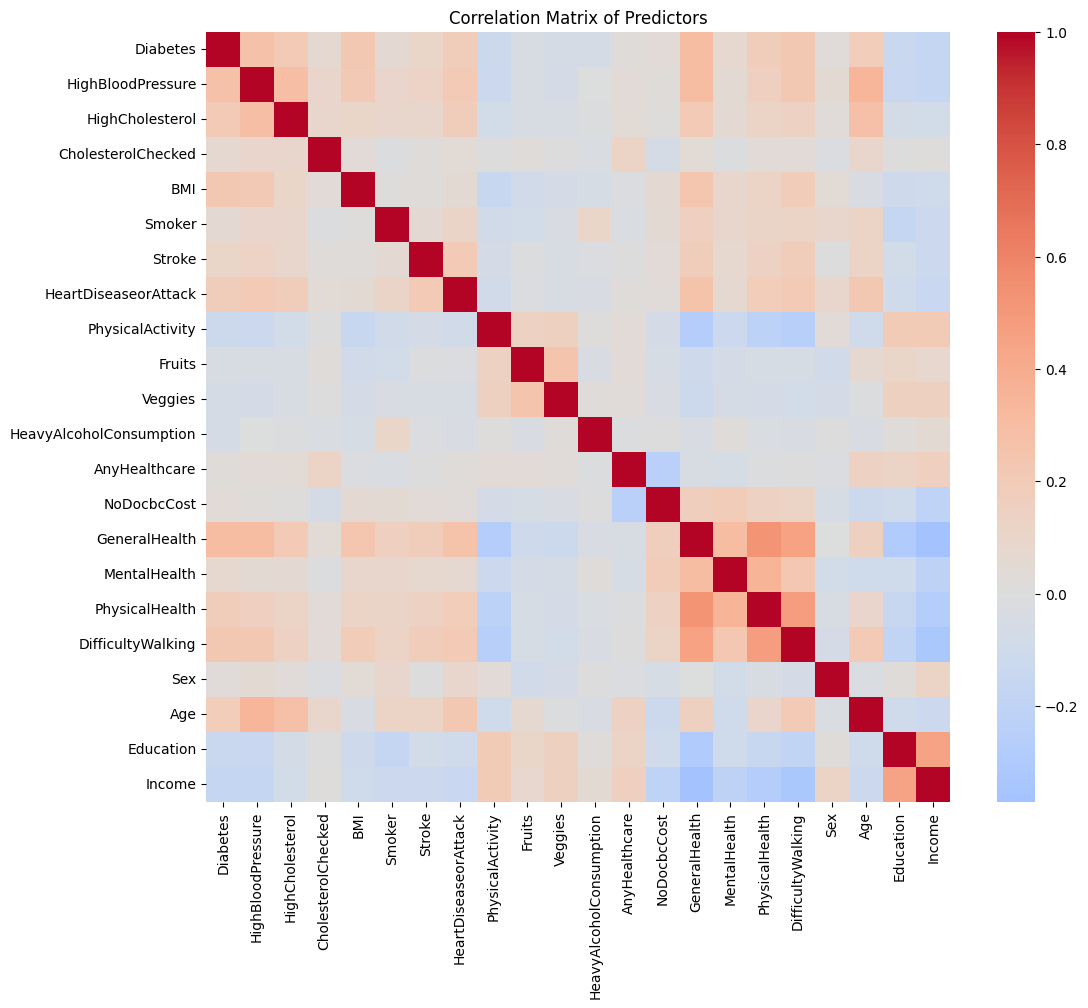

In [ ]:
# visualization to support

plt.figure(figsize=(12,10))
sns.heatmap(diabetes_df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Predictors")
plt.show()

8)From your EDA, compile your most important findings in a short paragraph. For each of your takeaways, point to specific tables or visualizations you generated that support your interpretations. Consider what this means for your final model.

**Answer: EDA shows that diabetes risk is most strongly associated with underlying health conditions, age, and BMI. The correlation matrix heatmap shows that variables such as HighBloodPressure, HighCholesterol, BMI, and engineered features like BMI_HighBP and BP_Chol have the strongest positive relationships with the outcome, indicating that compounded health risks are highly predictive. The grouped summary statistics and boxplots further show that BMI does not differ substantially by smoking status, while age is notably higher among smokers, suggesting interaction effects rather than direct relationships. Additionally, the value counts and distributions indicate that many predictors are binary or categorical, and the outcome variable is imbalanced. These findings suggest that a classification model is appropriate and that incorporating interaction terms and composite features will improve performance, while also being mindful of multicollinearity among related health variables.**

# **Considering Different Types of Models**

1. This research problem is classification, as we are predicting discrete, categorical labels of if a person is predicted to have diabetes, prediabetes, or no diabetes
2. This research problem is supervised learning, as we have the true value (diabetes, prediabetes, or no diabetes) for each observation
3. Given these attributes of my project, the potential models I could use is a classification decision tree since it's designed to predict categoricla outcome sand can handle multiple classes. Although linear regression and KNN regression were also discussed, they're primarily used for predicting continuous outcomes, so are not appropriate for this classification data.
4. The possible model that makes the most sense for my dataset is the classification decision tree since it can handle a mix of feature types and doesn't require strong assumptions about the relationships between variables. It is also able to capture nonlinear patterns in the data, which is useful when predicting complex conditions like diabetes.

5a. One example of feature engineering that will be helpful is looking at compounding health conditions and creating interaction terms to do so. This is significant because it's common that the coexistence of multiple health conditions (like high blood pressure and high cholesterol) increase the harmful effects of both conditions, making it worse when its in tandem. These interaction terms allow us to see these patterns.

In [ ]:
diabetes_df['BP_Chol'] = diabetes_df['HighBloodPressure'] * diabetes_df['HighCholesterol']
diabetes_df['BMI_HighBP'] = diabetes_df['BMI'] * diabetes_df['HighBloodPressure']
diabetes_df['Age_HighChol'] = diabetes_df['Age'] * diabetes_df['HighCholesterol']

6. There is a concern about overfitting. Decision trees can become too complex and fit in the training data too closely, especially after adding interaction terms, which increase the number of features. This makes the model more likely to capture noises instead of true pattern. Underfitting is a less of a concern since decision trees can model complex relationship

5b. EDA showed that individuals with HighBP, HighChol, Stroke, HeartDisease tend to co-occur, so it makes sense to create a new feature that encapsulates a composite health risk score rather than treating all of the features individually

In [ ]:
diabetes_df['HealthRiskScore'] = (
    diabetes_df['HighBloodPressure'] +
    diabetes_df['HighCholesterol'] +
    diabetes_df['Smoker'] +
    diabetes_df['Stroke'] +
    diabetes_df['HeartDiseaseorAttack']
)

# **Project Checkpoint 3**:

# **Creating the Model**

MODEL ONE with only raw features: Multinomial Logistic Regression Model. We chose to start with this model because the outcome has multiple categories (no diabetes, prediabetes, diabetes), and this model is designed for multi-class classification. It provides a simple and interpretable baseline, allowing us to see how each feature directly relates to the probability of belonging to each diabetes category. Using raw features first helps establish a benchmark performance before introducing more complex feature engineering.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define target and features, dropping any engineered features made in previous
# steps
y = diabetes_df['Diabetes']
X = diabetes_df.drop(columns=['Diabetes', 'BP_Chol', 'BMI_HighBP', 'Age_HighChol', 'HealthRiskScore'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (177576, 21)
Shape of y_train: (177576,)
Shape of X_test: (76104, 21)
Shape of y_test: (76104,)


Now, I will train a multinomial logistic regression model using the saga solver, which handles multinomial classification effectively, and then evaluate its accuracy on the test set.

In [ ]:
# Initialize and train the multinomial Logistic Regression model
# Using 'saga' solver for multinomial logistic regression, and 'multinomial' for multi_class
model_raw_features = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=1000, random_state=42, n_jobs=-1)
model_raw_features.fit(X_train, y_train)

# Make predictions on the test set
y_pred_raw_features = model_raw_features.predict(X_test)

# Evaluate the model
accuracy_raw_features = accuracy_score(y_test, y_pred_raw_features)
print(f"Accuracy of Multinomial Logistic Regression (Raw Features): {accuracy_raw_features:.4f}")

print("\nClassification Report (Raw Features):")
print(classification_report(y_test, y_pred_raw_features))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy of Multinomial Logistic Regression (Raw Features): 0.8463

Classification Report (Raw Features):
              precision    recall  f1-score   support

           0       0.86      0.98      0.92     64111
           1       0.00      0.00      0.00      1389
           2       0.52      0.18      0.26     10604

    accuracy                           0.85     76104
   macro avg       0.46      0.38      0.39     76104
weighted avg       0.80      0.85      0.81     76104



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Based on the classification report, the model does well with predicting instances of no diabetes, struggles with predicting instances of diabetes, and is unable to predict instances of prediabetes.

Model Two: Feature Space Engineering Model. We examine how the multinomial logistic regression model performs using the interaction terms created in Checkpoint 2 that capture composite health effects, while incorporating regularization through Lasso (L1) and Ridge (L2). We will use Lasso and Ridge for all of our next models, as these penalties are especially important with engineered features, as they help control overfitting by either selecting the most relevant features (L1) or shrinking coefficients to stabilize the model (L2), allowing the models to capture more complex relationships while maintaining interpretability.

In [ ]:
# Define target and features, including the engineered features
y_engineered = diabetes_df['Diabetes']
X_engineered = diabetes_df.drop(columns=['Diabetes'])

# Split data into training and testing sets for the engineered features model
X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(X_engineered, y_engineered, test_size=0.3, random_state=42, stratify=y_engineered)

print(f"Shape of X_train_engineered: {X_train_engineered.shape}")
print(f"Shape of y_train_engineered: {y_train_engineered.shape}")
print(f"Shape of X_test_engineered: {X_test_engineered.shape}")
print(f"Shape of y_test_engineered: {y_test_engineered.shape}")

Shape of X_train_engineered: (177576, 25)
Shape of y_train_engineered: (177576,)
Shape of X_test_engineered: (76104, 25)
Shape of y_test_engineered: (76104,)


In [ ]:
# Initialize and train the multinomial Logistic Regression model with engineered features and L1 penalty (Lasso)
model_engineered_features_l1 = LogisticRegression(multi_class='multinomial', solver='saga', penalty='l1', max_iter=1000, random_state=42, n_jobs=-1)
model_engineered_features_l1.fit(X_train_engineered, y_train_engineered)

# Make predictions on the test set for L1 model
y_pred_engineered_features_l1 = model_engineered_features_l1.predict(X_test_engineered)

# Evaluate the L1 model
accuracy_engineered_features_l1 = accuracy_score(y_test_engineered, y_pred_engineered_features_l1)
print(f"Accuracy of Multinomial Logistic Regression (Engineered Features, L1 Penalty): {accuracy_engineered_features_l1:.4f}")

print("\nClassification Report (Engineered Features, L1 Penalty):")
print(classification_report(y_test_engineered, y_pred_engineered_features_l1))

# Initialize and train the multinomial Logistic Regression model with engineered features and L2 penalty (Ridge)
model_engineered_features_l2 = LogisticRegression(multi_class='multinomial', solver='saga', penalty='l2', max_iter=1000, random_state=42, n_jobs=-1)
model_engineered_features_l2.fit(X_train_engineered, y_train_engineered)

# Make predictions on the test set for L2 model
y_pred_engineered_features_l2 = model_engineered_features_l2.predict(X_test_engineered)

# Evaluate the L2 model
accuracy_engineered_features_l2 = accuracy_score(y_test_engineered, y_pred_engineered_features_l2)
print(f"\nAccuracy of Multinomial Logistic Regression (Engineered Features, L2 Penalty): {accuracy_engineered_features_l2:.4f}")

print("\nClassification Report (Engineered Features, L2 Penalty):")
print(classification_report(y_test_engineered, y_pred_engineered_features_l2))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

Accuracy of Multinomial Logistic Regression (Engineered Features, L1 Penalty): 0.8468

Classification Report (Engineered Features, L1 Penalty):
              precision    recall  f1-score   support

           0       0.86      0.98      0.92     64111
           1       0.00      0.00      0.00      1389
           2       0.53      0.17      0.26     10604

    accuracy                           0.85     76104
   macro avg       0.46      0.38      0.39     76104
weighted avg       0.80      0.85      0.81     76104


Accuracy of Multinomial Logistic Regression (Engineered Features, L2 Penalty): 0.8468

Classification Report (Engineered Features, L2 Penalty):
              precision    recall  f1-score   support

           0       0.86      0.98      0.92     64111
           1       0.00      0.00      0.00      1389
           2       0.53      0.17      0.26     10604

    accuracy                           0.85     76104
   macro avg       0.46      0.38      0.39     76104
weig

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use

Using engineered features, the model accuracy slightly increased  84.88 vs 84.63%.

In [ ]:
diabetes_df['Diabetes'].value_counts()
print(diabetes_df['Diabetes'].value_counts(normalize = True))

Diabetes
0    0.842412
2    0.139333
1    0.018255
Name: proportion, dtype: float64


The outcome variable has very unbalanced set of observations which is affecting model accuracy at predicting cases of diabetes and prediabetes as there are an overwhelming amount of observations that do not have diabetes.

Fitting at least one other model family: KNN model. A KNN model could be useful to look at because it provides a simple, non-parametric baseline that does not assume a linear relationship between the features and diabetes classification. Instead, it classifies individuals based on the most similar observations in the dataset, which can help capture local patterns that logistic regression might miss.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_engineered, y_train_engineered)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_engineered)

# Evaluate the model
accuracy_knn = accuracy_score(y_test_engineered, y_pred_knn)
print(f"Accuracy of KNN Model: {accuracy_knn:.4f}")

print("\nClassification Report (KNN Model):")
print(classification_report(y_test_engineered, y_pred_knn))

Accuracy of KNN Model: 0.8335

Classification Report (KNN Model):
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     64111
           1       0.03      0.00      0.00      1389
           2       0.42      0.20      0.27     10604

    accuracy                           0.83     76104
   macro avg       0.44      0.39      0.39     76104
weighted avg       0.79      0.83      0.80     76104



While the KNN model has lower accuracy, the benefit is that it has increased ability to predict cases of prediabetes as compared to other previous models.

Random Forest Classifier with Engineered Features: A Random Forest Classifier with engineered features may be useful because it can capture complex, non-linear relationships and interactions that simpler models may miss. By incorporating engineered features (such as interaction or polynomial terms), the model is given more informative inputs that can better reflect patterns in the data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model on the original training data (without SMOTE)
# n_estimators can be tuned, but starting with a reasonable number like 100
# n_jobs=-1 to utilize all available CPU cores for faster training
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
model_rf.fit(X_train_engineered, y_train_engineered)

# Make predictions on the original (unbalanced) test set
y_pred_rf = model_rf.predict(X_test_engineered)

# Evaluate the model
accuracy_rf = accuracy_score(y_test_engineered, y_pred_rf)
print(f"Accuracy of Random Forest (Engineered Features): {accuracy_rf:.4f}")

print("\nClassification Report (Random Forest with Engineered Features):")
print(classification_report(y_test_engineered, y_pred_rf))

Accuracy of Random Forest (Engineered Features): 0.8387

Classification Report (Random Forest with Engineered Features):
              precision    recall  f1-score   support

           0       0.86      0.97      0.91     64111
           1       0.00      0.00      0.00      1389
           2       0.47      0.17      0.25     10604

    accuracy                           0.84     76104
   macro avg       0.44      0.38      0.39     76104
weighted avg       0.79      0.84      0.80     76104



The random forest with engineered features model has a lower accuracy than the logistic regression models, but a slightly higher accuracy than the KNN model. One disadvantage is that this model is unable to predict prediabetes.

Model evaluation use cross validation:

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Prepare Data: Convert boolean columns to integers (0/1) for pipeline compatibility ---
# Standard Scaler and Logistic Regression/KNN expect numeric input.

X_raw_numeric = X.copy()
for col in X_raw_numeric.select_dtypes(include='bool').columns:
    X_raw_numeric[col] = X_raw_numeric[col].astype(int)

X_engineered_numeric = X_engineered.copy()
for col in X_engineered_numeric.select_dtypes(include='bool').columns:
    X_engineered_numeric[col] = X_engineered_numeric[col].astype(int)

# --- Define Pipelines for each model ---

# Model 1: Logistic Regression (Raw Features)
# Scaling is good for Logistic Regression
model1_lr_raw_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='saga', max_iter=1000, random_state=42, n_jobs=-1))
])

# Model 2: Logistic Regression (Engineered Features)
model2_lr_engineered_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='saga', max_iter=1000, random_state=42, n_jobs=-1))
])

# Model 3: KNN (Engineered Features)
# KNN is distance-based, so scaling is crucial
model3_knn_engineered_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])

# Model 4: Random Forest (Engineered Features)
# Scaling is often less critical for tree-based models but can sometimes help.
model4_rf_engineered_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'))
])

# --- Perform Cross-Validation ---

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Starting Cross-Validation...")

# Evaluate Model 1: Logistic Regression (Raw Features)
print("\nEvaluating Logistic Regression (Raw Features)...")
scores_lr_raw = cross_val_score(model1_lr_raw_pipeline, X_raw_numeric, y, cv=kf, scoring='f1_weighted', n_jobs=-1)
results['LR_Raw_Features'] = {'mean_f1_weighted': scores_lr_raw.mean(), 'std_f1_weighted': scores_lr_raw.std()}
print(f"Mean F1-Weighted: {scores_lr_raw.mean():.4f}, Std F1-Weighted: {scores_lr_raw.std():.4f}")

# Evaluate Model 2: Logistic Regression (Engineered Features)
print("\nEvaluating Logistic Regression (Engineered Features)...")
scores_lr_engineered = cross_val_score(model2_lr_engineered_pipeline, X_engineered_numeric, y_engineered, cv=kf, scoring='f1_weighted', n_jobs=-1)
results['LR_Engineered_Features'] = {'mean_f1_weighted': scores_lr_engineered.mean(), 'std_f1_weighted': scores_lr_engineered.std()}
print(f"Mean F1-Weighted: {scores_lr_engineered.mean():.4f}, Std F1-Weighted: {scores_lr_engineered.std():.4f}")

# Evaluate Model 3: KNN (Engineered Features)
print("\nEvaluating KNN (Engineered Features)...")
scores_knn_engineered = cross_val_score(model3_knn_engineered_pipeline, X_engineered_numeric, y_engineered, cv=kf, scoring='f1_weighted', n_jobs=-1)
results['KNN_Engineered_Features'] = {'mean_f1_weighted': scores_knn_engineered.mean(), 'std_f1_weighted': scores_knn_engineered.std()}
print(f"Mean F1-Weighted: {scores_knn_engineered.mean():.4f}, Std F1-Weighted: {scores_knn_engineered.std():.4f}")

# Evaluate Model 4: Random Forest (Engineered Features)
print("\nEvaluating Random Forest (Engineered Features)...")
scores_rf_engineered = cross_val_score(model4_rf_engineered_pipeline, X_engineered_numeric, y_engineered, cv=kf, scoring='f1_weighted', n_jobs=-1)
results['RF_Engineered_Features'] = {'mean_f1_weighted': scores_rf_engineered.mean(), 'std_f1_weighted': scores_rf_engineered.std()}
print(f"Mean F1-Weighted: {scores_rf_engineered.mean():.4f}, Std F1-Weighted: {scores_rf_engineered.std():.4f}")


print("\n--- Final Cross-Validation Results (F1-Weighted Score) ---")
for model_name, metrics in results.items():
    print(f"{model_name}: Mean F1-Weighted = {metrics['mean_f1_weighted']:.4f}, Std F1-Weighted = {metrics['std_f1_weighted']:.4f}")

Starting Cross-Validation...

Evaluating Logistic Regression (Raw Features)...
Mean F1-Weighted: 0.8078, Std F1-Weighted: 0.0005

Evaluating Logistic Regression (Engineered Features)...
Mean F1-Weighted: 0.8080, Std F1-Weighted: 0.0005

Evaluating KNN (Engineered Features)...
Mean F1-Weighted: 0.8011, Std F1-Weighted: 0.0007

Evaluating Random Forest (Engineered Features)...
Mean F1-Weighted: 0.8012, Std F1-Weighted: 0.0006

--- Final Cross-Validation Results (F1-Weighted Score) ---
LR_Raw_Features: Mean F1-Weighted = 0.8078, Std F1-Weighted = 0.0005
LR_Engineered_Features: Mean F1-Weighted = 0.8080, Std F1-Weighted = 0.0005
KNN_Engineered_Features: Mean F1-Weighted = 0.8011, Std F1-Weighted = 0.0007
RF_Engineered_Features: Mean F1-Weighted = 0.8012, Std F1-Weighted = 0.0006


The logistic regression model using raw features achieved a mean F1-weighted score of 0.8078 with a low standard deviation of 0.0005, while the logistic regression model with engineered features slightly outperformed it with a mean F1-score of 0.8080 and the same low standard deviation of 0.0005. The low standard deviation indicates a very consistent performance across the different folds during cross validation for both of these models. The random forest model using engineered features had a lower F1 score (0.8012) than both logistic regression models, indicating slightly lower performance, although its standard deviation (0.0006) was still low, showing strong consistency across data splits. Similarly, the KNN model with engineered features had a slightly lower F1 score (0.8011) and the highest standard deviation (0.0007), suggesting it was both less effective and slightly less consistent compared to the other models. One way that our models could be improved is through addressing class imbalance using techniques such as SMOTE, which generates synthetic examples of the minority (diabetes) class to create a more balanced training set. This could improve the model’s ability to correctly identify diabetes cases, potentially increasing recall and our F1-score.